In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.metrics import accuracy_score, f1_score, recall_score, confusion_matrix, classification_report, precision_score
from sklearn.metrics import roc_curve, auc
from sklearn.preprocessing import MinMaxScaler
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier
from sklearn.cluster import KMeans

In [2]:
ecom_df = pd.read_csv("Ecommerce.csv")
ecom_df.head()

,customer_id,session_id,visit_date,device_type,user_type,marketing_channel,product_id,product_category,unit_price,quantity,...,review_text,review_helpful_votes,payment_method,visit_day,visit_month,visit_weekday,visit_season,session_duration_bucket,revenue_normalized,location
0,1803,0,28-11-2024,2,1,2,894,6,651.57,1,...,1,0,1,28,11,3,0,Long,0.000000,209
1,7964,1,25-09-2024,2,0,4,844,2,945.27,4,...,1,0,2,25,9,2,0,Long,0.000000,213
2,6890,2,31-05-2024,1,1,0,865,0,400.44,4,...,1,0,2,31,5,4,1,Short,0.000000,10
3,4949,3,30-01-2024,1,0,2,851,3,1268.54,2,...,10,4,1,30,1,1,3,Very Long,0.305504,46
4,4896,4,25-02-2024,1,1,5,794,3,880.81,3,...,1,0,1,25,2,6,3,Very Short,0.000000,118


In [3]:
ecom_df.info()
ecom_df.isnull().sum()
ecom_df.duplicated().sum()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25000 entries, 0 to 24999
Data columns (total 29 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   customer_id              25000 non-null  int64  
 1   session_id               25000 non-null  int64  
 2   visit_date               25000 non-null  object 
 3   device_type              25000 non-null  int64  
 4   user_type                25000 non-null  int64  
 5   marketing_channel        25000 non-null  int64  
 6   product_id               25000 non-null  int64  
 7   product_category         25000 non-null  int64  
 8   unit_price               25000 non-null  float64
 9   quantity                 25000 non-null  int64  
 10  discount_percent         25000 non-null  int64  
 11  discount_amount          25000 non-null  float64
 12  revenue                  25000 non-null  float64
 13  pages_viewed             25000 non-null  int64  
 14  time_on_site_sec      

np.int64(0)

In [4]:
ecom_df.columns

Index(['customer_id', 'session_id', 'visit_date', 'device_type', 'user_type',
       'marketing_channel', 'product_id', 'product_category', 'unit_price',
       'quantity', 'discount_percent', 'discount_amount', 'revenue',
       'pages_viewed', 'time_on_site_sec', 'added_to_cart', 'purchased',
       'cart_abandoned', 'rating', 'review_text', 'review_helpful_votes',
       'payment_method', 'visit_day', 'visit_month', 'visit_weekday',
       'visit_season', 'session_duration_bucket', 'revenue_normalized',
       'location'],
      dtype='object')

In [5]:
ecom_df = ecom_df.drop(['customer_id','session_id','visit_date'], axis=1)

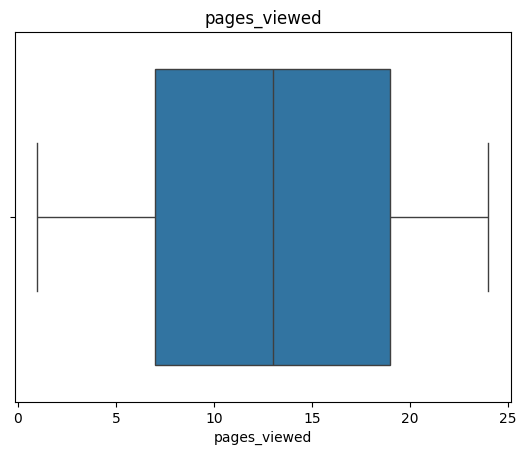

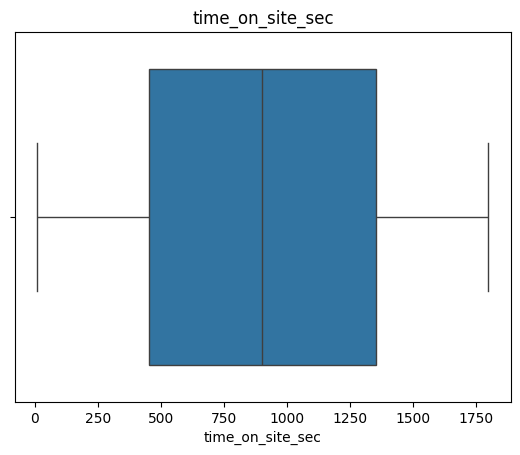

In [6]:
cols = ['pages_viewed', 'time_on_site_sec']

for col in cols:
    sns.boxplot(x=ecom_df[col])
    plt.title(col)
    plt.show()

In [7]:
#Encoding

In [8]:
le = LabelEncoder()
ecom_df['session_duration_bucket'] = le.fit_transform(ecom_df['session_duration_bucket'])

In [9]:
# Correlation Matrix

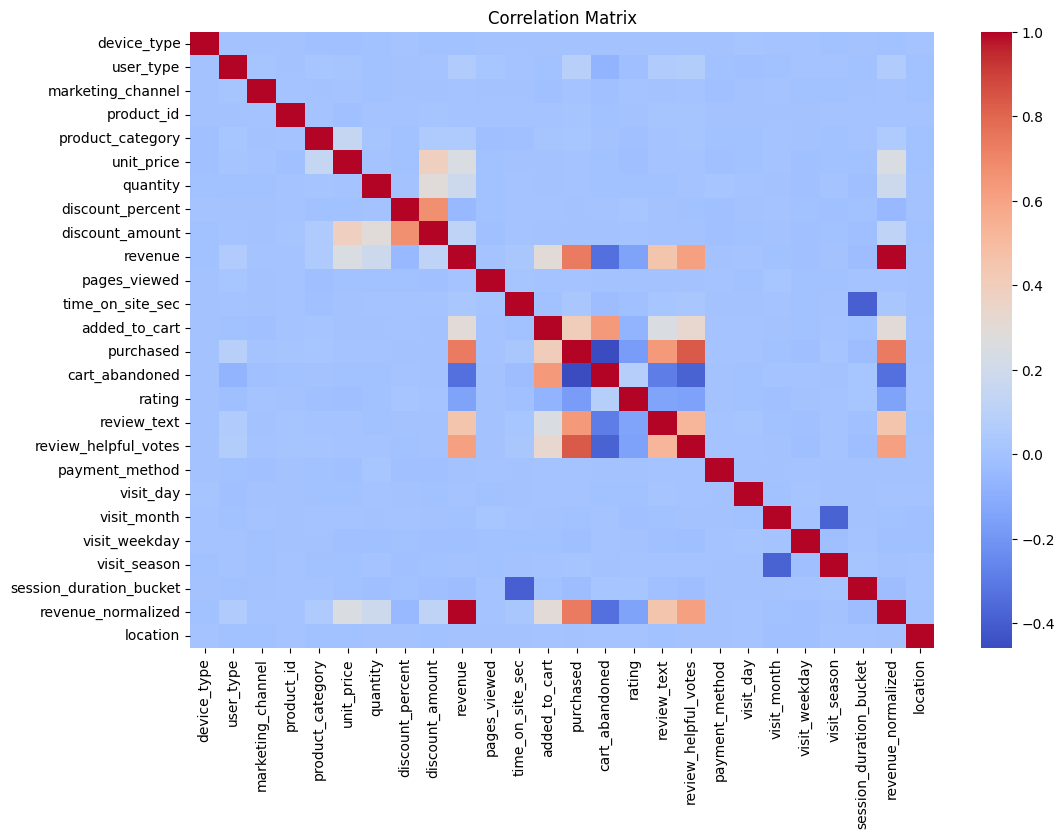

In [10]:
plt.figure(figsize=(12,8))
sns.heatmap(ecom_df.corr(), cmap='coolwarm')
plt.title("Correlation Matrix")
plt.show()

In [11]:
ecom_df = ecom_df.drop([
    'cart_abandoned',
    'revenue_normalized',
    'unit_price',
    'quantity',
    'discount_amount'], axis=1)

# Probability

In [12]:
# Probability that a customer makes a purchase
purchase_probability = ecom_df['purchased'].mean()
print("Probability of Purchase:", purchase_probability)

Probability of Purchase: 0.22464


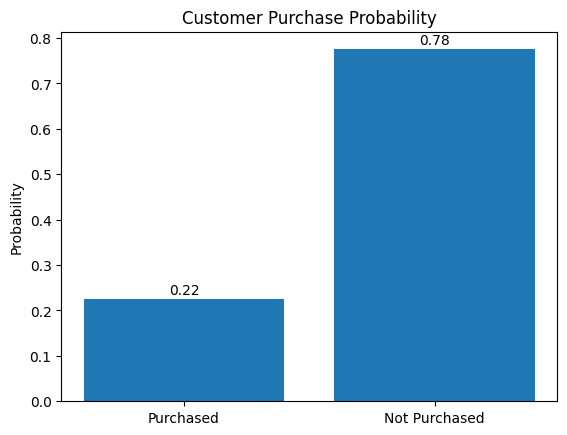

In [13]:
# Visuals 
purchase_prob = ecom_df['purchased'].mean()
no_purchase_prob = 1 - purchase_prob

labels = ['Purchased', 'Not Purchased']
values = [purchase_prob, no_purchase_prob]

plt.bar(labels, values)
plt.ylabel("Probability")
plt.title("Customer Purchase Probability")

for i, v in enumerate(values):
    plt.text(i, v + 0.01, f"{v:.2f}", ha='center')

plt.show()

# Business Explanation

Out of all visitors, only around 22 out of 100 customers actually purchase a product.

This indicates:Low conversion rate. Majority of users are just browsing, not buying

In [14]:
# What is the probability of purchase given higher time on site?
# 300 Sec 
threshold = 300

high_time = ecom_df[ecom_df['time_on_site_sec'] > threshold]

high_prob = high_time['purchased'].mean()
high_prob

np.float64(0.23078395711687566)

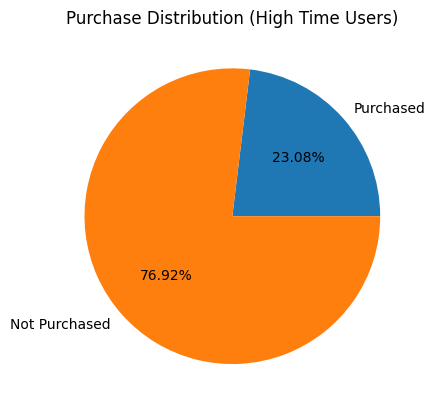

In [15]:
purchase_prob = high_prob
no_purchase_prob = 1 - purchase_prob

labels = ['Purchased', 'Not Purchased']
values = [purchase_prob, no_purchase_prob]

plt.pie(values, labels=labels, autopct='%1.2f%%')
plt.title("Purchase Distribution (High Time Users)")

plt.show()

# Business Insight

Higher time on site slightly increases the probability of purchase, but the improvement is minimal.

This means: Time spent ≠ strong buying intent. Users may explore but not convert.

Increasing time on site alone is not enough to significantly improve sales. 
Additional strategies like better product targeting, offers, or checkout optimization are needed.

In [16]:
# What is the probability of purchase for each session duration bucket?

bucket_prob = ecom_df.groupby('session_duration_bucket')['purchased'].mean()
bucket_prob_df = bucket_prob.reset_index()
bucket_prob_df.columns = ['Session Bucket', 'Purchase Probability']
print(bucket_prob_df)

   Session Bucket  Purchase Probability
0               0              0.236169
1               1              0.227870
2               2              0.232212
3               3              0.202392


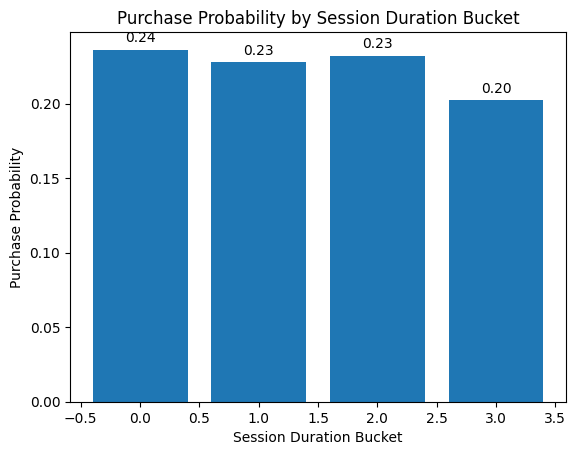

In [17]:
plt.bar(bucket_prob_df['Session Bucket'], bucket_prob_df['Purchase Probability'])

plt.xlabel("Session Duration Bucket")
plt.ylabel("Purchase Probability")
plt.title("Purchase Probability by Session Duration Bucket")

# Show values
for i, v in enumerate(bucket_prob_df['Purchase Probability']):
    plt.text(i, v + 0.005, f"{v:.2f}", ha='center')

plt.show()

# Business Insight

Spending more time on the website does NOT guarantee higher purchase.

Possible reasons:

Users may be confused or stuck.
Long sessions ≠ buying intent.
Users might be comparing products but not converting.

Session duration alone is not a strong driver of purchase behavior. Other factors like pricing, product relevance, or user experience may play a bigger role. 

# T-Test (Two Sample T-Test)

In [18]:
# Do customers who purchase view more pages than those who don’t?
Hypothesis
H0: μ₁ = μ₂ (No difference in average pages viewed between buyers and non-buyers)

H1: μ₁ > μ₂ (Customers who purchase view more pages than those who don’t)

SyntaxError: invalid character '₁' (U+2081) (2285678637.py, line 3)

In [ ]:
import numpy as np
from scipy.stats import ttest_ind

# Buyers
purchased = ecom_df[ecom_df['purchased'] == 1]['pages_viewed']
x1_bar = purchased.mean()
s1 = purchased.std()
n1 = len(purchased)

# Non-buyers
not_purchased = ecom_df[ecom_df['purchased'] == 0]['pages_viewed']
x2_bar = not_purchased.mean()
s2 = not_purchased.std()
n2 = len(not_purchased)

alpha = 0.05

# Perform T-test
t_statistic, p_value = ttest_ind(purchased, not_purchased)

# Print values
print(f"Mean Pages Viewed (Buyers): {x1_bar:.4f}")
print(f"Std Dev (Buyers): {s1:.4f}")
print(f"Sample Size (Buyers): {n1}")

print(f"\nMean Pages Viewed (Non-Buyers): {x2_bar:.4f}")
print(f"Std Dev (Non-Buyers): {s2:.4f}")
print(f"Sample Size (Non-Buyers): {n2}")

print(f"\nSignificance Level (α): {alpha}")

print(f"\nCalculated T-statistic: {t_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

# Decision
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.6f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: Customers who purchase view significantly more pages.")
else:
    print(f"\nSince the p-value ({p_value:.6f}) is not less than alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is not sufficient evidence to say buyers view more pages.")

# Interpretations:

We fail to reject the null hypothesis because the p-value is greater than 0.05, indicating that the difference in pages viewed between buyers and non-buyers is not statistically significant.

# Two-Sample Z-Test (Independent Samples)

In [ ]:
# Do customers who purchase spend more time on the website than those who don’t?

H0: μ₁ = μ₂
(No difference in average time between buyers and non-buyers)

H1: μ₁ > μ₂
(Customers who purchase spend more time than those who don’t)

In [ ]:
import numpy as np
from scipy.stats import norm

# Given values from dataset

# Buyers
purchased = ecom_df[ecom_df['purchased'] == 1]['time_on_site_sec']
x1_bar = purchased.mean()
sigma1 = purchased.std()
n1 = len(purchased)

# Non-buyers
not_purchased = ecom_df[ecom_df['purchased'] == 0]['time_on_site_sec']
x2_bar = not_purchased.mean()
sigma2 = not_purchased.std()
n2 = len(not_purchased)

alpha = 0.05  # Significance level

# Hypotheses:
# H0: mu1 = mu2 (No difference in average time)
# H1: mu1 > mu2 (Buyers spend more time)

# Calculate Z-statistic
z_statistic = (x1_bar - x2_bar) / np.sqrt((sigma1**2 / n1) + (sigma2**2 / n2))

# Right-tailed test
p_value = 1 - norm.cdf(z_statistic)

# Print values
print(f"Sample Mean (Buyers): {x1_bar:.4f}")
print(f"Std Dev (Buyers): {sigma1:.4f}")
print(f"Sample Size (Buyers): {n1}")

print(f"\nSample Mean (Non-Buyers): {x2_bar:.4f}")
print(f"Std Dev (Non-Buyers): {sigma2:.4f}")
print(f"Sample Size (Non-Buyers): {n2}")

print(f"\nSignificance Level (α): {alpha}")

print(f"\nCalculated Z-statistic: {z_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

# Decision
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.6f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: Customers who purchase spend significantly more time on the website.")
else:
    print(f"\nSince the p-value ({p_value:.6f}) is not less than alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is not sufficient evidence to say that buyers spend more time.")

# Interpretation

We reject the null hypothesis because the p-value is much smaller than the significance level (0.05), 
indicating that the observed difference in time spent is statistically significant and not due to random variation.

# Chi-Square Test 

In [ ]:
# Is there a relationship between session duration bucket and purchase behavior?
Hypotheses

H0: Variables are independent (No relationship between session duration and purchase)

H1: Variables are dependent (Session duration affects purchase)

In [ ]:
import numpy as np
from scipy.stats import chi2_contingency

# Create contingency table
contingency_table = pd.crosstab(
    ecom_df['session_duration_bucket'],
    ecom_df['purchased']
)

# Significance level
alpha = 0.05

# Perform Chi-Square Test
chi2_statistic, p_value, dof, expected = chi2_contingency(contingency_table)

# Print values
print("Contingency Table:\n")
print(contingency_table)

print(f"\nDegrees of Freedom: {dof}")
print(f"Significance Level (α): {alpha}")

print(f"\nCalculated Chi-Square Statistic: {chi2_statistic:.4f}")
print(f"P-value: {p_value:.6f}")

# Decision
if p_value < alpha:
    print(f"\nSince the p-value ({p_value:.6f}) is less than alpha ({alpha}), we reject the null hypothesis.")
    print("Conclusion: There is a significant relationship between session duration and purchase behavior.")
else:
    print(f"\nSince the p-value ({p_value:.6f}) is not less than alpha ({alpha}), we fail to reject the null hypothesis.")
    print("Conclusion: There is no significant relationship between session duration and purchase behavior.")

# Interpretation:

We reject the null hypothesis because the p-value is less than 0.05, 
indicating that session duration and purchase behavior are statistically dependent and the observed differences are not due to chance.

In [ ]:
# CLT(Central Limit Theoram)

In [ ]:
data = ecom_df['pages_viewed']

sample_means = []
num_samples = 1000
sample_size = 30

for i in range(num_samples):
    sample = np.random.choice(data, size=sample_size)
    sample_means.append(np.mean(sample))

In [ ]:
data = ecom_df['pages_viewed']
plt.figure(figsize=(12,5))

# Original data
plt.subplot(1,2,1)
sns.histplot(data, kde=True)
plt.title("Original Data (Pages Viewed)")

# Sample means
plt.subplot(1,2,2)
sns.histplot(sample_means, kde=True)
plt.title("CLT - Sample Means Distribution")

plt.show()

# Interpretation
The original data (pages viewed) is spread out and does not follow a clear pattern. However, when we take sample averages, the distribution becomes smooth and forms a bell-shaped curve.

## Logistic Regression

In [ ]:
X = ecom_df[['pages_viewed', 'time_on_site_sec','session_duration_bucket','review_helpful_votes']]
y = ecom_df['purchased']
# Split data
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Check shapes
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

In [ ]:
model = LogisticRegression(max_iter=1000, class_weight='balanced')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

In [ ]:
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("Accuracy:", accuracy_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))

In [ ]:
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
cm = confusion_matrix(y_test, y_pred)

sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix - Ecommerce Model")

plt.show()

In [ ]:
y_score = model.predict_proba(X_test)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_score)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f"ROC curve (AUC = {roc_auc:.2f})")

x_point = [0, 1]
y_point = [0, 1]
plt.plot(x_point, y_point, linestyle="--", color="gray")

plt.xlabel("False positive rate")
plt.ylabel("True positive rate")
plt.title("ROC AUC Curve - Ecommerce Purchase Prediction")
plt.legend()

plt.show()

In [ ]:
new_data = pd.DataFrame({
    'pages_viewed': [8],
    'time_on_site_sec': [300],
    'session_duration_bucket': [2],   
    'review_helpful_votes': [5]
})

prediction = model.predict(new_data)
probability = model.predict_proba(new_data)

print("Prediction (0 = No Purchase, 1 = Purchase):", prediction[0])
print("Purchase Probability:", probability[0][1])

In [ ]:
#KNN

In [ ]:
X = ecom_df[['pages_viewed', 'time_on_site_sec','session_duration_bucket', 'review_helpful_votes']].values
y = ecom_df['purchased'].values

# Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Scaling
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [ ]:
accuracy = []

for k in range(1, 11):
    knn = KNeighborsClassifier(n_neighbors=k)
    knn.fit(X_train, y_train)
    y_pred = knn.predict(X_test)
    accuracy.append(accuracy_score(y_test, y_pred))

plt.plot(range(1, 11), accuracy, marker='o')
plt.xlabel("K Value")
plt.ylabel("Accuracy")
plt.title("K vs Accuracy")

plt.show()

In [ ]:
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))

In [ ]:
k = 5
knn_model = KNeighborsClassifier(n_neighbors=k)
knn_model.fit(X_train, y_train)

In [ ]:
new_data2 = pd.DataFrame({
    'pages_viewed': [8],
    'time_on_site_sec': [300],
    'session_duration_bucket': [2],   
    'review_helpful_votes': [5]
})

new_data2_scaled = scaler.transform(new_data2)

# Prediction
prediction = knn_model.predict(new_data2_scaled)

# Probability
probability = knn_model.predict_proba(new_data2_scaled)

print("KNN Prediction (0 = No Purchase, 1 = Purchase):", prediction[0])
print("Purchase Probability:", probability[0][1])

In [ ]:
#KMeans Clustering

In [ ]:
X_cluster = ecom_df[['pages_viewed',
                   'review_helpful_votes']]

In [ ]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_cluster)

In [ ]:
inertia = []

for k in range(1, 11):
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.plot(range(1, 11), inertia, marker='o')
plt.xlabel("Number of Clusters")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

In [ ]:
kmeans = KMeans(n_clusters=4, random_state=42)
clusters = kmeans.fit_predict(X_scaled)
ecom_df['Cluster'] = clusters
kmeans

In [ ]:
cluster_centroids_3 = kmeans.cluster_centers_
cluster_centroids_3

In [ ]:
plt.figure(figsize=(6,4))

plt.scatter(ecom_df['pages_viewed'],
            ecom_df['review_helpful_votes'],
            c=ecom_df['Cluster'],  
            cmap='viridis')         

plt.xlabel("Pages Viewed")
plt.ylabel("Review Helpful Votes")
plt.title("Customer Segments")

plt.colorbar(label='Cluster')

plt.show()

In [ ]:
plt.scatter(X_scaled[:,0], X_scaled[:,1], marker='.', color='orange')

plt.scatter(-1.23896794, -0.38657903, s=50, c='r')
plt.scatter(1.3615711, -0.37933973, s=50, c='g')
plt.scatter(-0.8869767, 2.27884622, s=50, c='b')
plt.scatter(0.86240892, 2.27197927, s=50, c='black')
plt.scatter(0.57687922, -0.38313719, s=50, c='yellow')

plt.xlabel("Pages Viewed (scaled)")
plt.ylabel("Review Helpful Votes (scaled)")
plt.title("KMeans Clustering - Ecommerce")

plt.show()

In [ ]:
# Data points (scaled)
plt.scatter(X_scaled[:, 0], X_scaled[:, 1], marker='.', color='orange')

# Centroids (from model output - first 2 dimensions only)
centroids = kmeans.cluster_centers_

# Cluster 0
plt.scatter(centroids[0][0], centroids[0][1], s=80, c='r')

# Cluster 1
plt.scatter(centroids[1][0], centroids[1][1], s=80, c='g')

# Cluster 2
plt.scatter(centroids[2][0], centroids[2][1], s=80, c='b')

# Cluster 3
plt.scatter(centroids[3][0], centroids[3][1], s=80, c='black')

#Cluster 4
plt.scatter(centroids[4][0], centroids[4][1], s=80, c='yellow')

#plt.xlabel("x (scaled)")
#plt.ylabel("Time on Site (scaled)")
plt.title("KMeans Clustering - Ecommerce (Updated Centroids)")

In [ ]:
from sklearn.metrics import silhouette_score

score = silhouette_score(X_scaled, clusters)
print("Silhouette Score:", score)

In [ ]:
from sklearn.metrics import silhouette_score

silhouette_scores = []
for k in range(2, 11):  
    kmeans = KMeans(n_clusters=k, random_state=42)
    labels = kmeans.fit_predict(X_scaled)
    score = silhouette_score(X_scaled, labels)
    silhouette_scores.append(score)
    print(f"K = {k}, Silhouette Score = {score:.4f}")

In [ ]:
from sklearn.metrics import silhouette_samples, silhouette_score
import matplotlib.pyplot as plt
import numpy as np
import matplotlib.cm as cm

range_n_clusters = range(2, 7)   
for n_clusters in range_n_clusters:
    
    fig, ax1 = plt.subplots(1, 1)
    fig.set_size_inches(6, 4)
    kmeans = KMeans(n_clusters=n_clusters, random_state=42)
    cluster_labels = kmeans.fit_predict(X_scaled)

    silhouette_avg = silhouette_score(X_scaled, cluster_labels)
    print(f"For n_clusters = {n_clusters}, Silhouette Score = {silhouette_avg:.4f}")
    sample_silhouette_values = silhouette_samples(X_scaled, cluster_labels)
    y_lower = 10
    
    for i in range(n_clusters):
        ith_cluster_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_values.sort()

        size_cluster_i = ith_cluster_values.shape[0]
        y_upper = y_lower + size_cluster_i

        color = cm.nipy_spectral(float(i) / n_clusters)
        ax1.fill_betweenx(np.arange(y_lower, y_upper),
                          0, ith_cluster_values,
                          facecolor=color, edgecolor=color, alpha=0.7)

        ax1.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i))
        y_lower = y_upper + 10

    ax1.axvline(x=silhouette_avg, color="red", linestyle="--")
    ax1.set_title(f"Silhouette Plot for K = {n_clusters}")
    ax1.set_xlabel("Silhouette Coefficient Values")
    ax1.set_ylabel("Cluster Label")
    ax1.set_yticks([])
    ax1.set_xticks([-0.1, 0, 0.2, 0.4, 0.6, 0.8, 1])
    plt.show()